<a href="https://colab.research.google.com/github/luizkrawiec/estatistics/blob/main/Teste_de_Hipotese_T.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [29]:
import pandas as pd
import numpy as np
import plotly.express as px
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats
import statsmodels
from statsmodels.stats.diagnostic import lilliefors

In [14]:
enem_sp = pd.read_csv('/content/enem_2019_tratado.csv', sep=',', encoding='ISO-8859-1')

In [15]:
enem_sp.head()

,NU_INSCRICAO,NO_MUNICIPIO_RESIDENCIA,IDADE,SEXO,TP_ESTADO_CIVIL,RACA,TP_NACIONALIDADE,TP_ST_CONCLUSAO,ESCOLA,CO_ESCOLA,...,NOTA_MT,TP_LINGUA,TP_STATUS_REDACAO,COMP1,COMP2,COMP3,COMP4,COMP5,NOTA_REDACAO,INTERNET
0,"1,90E+11",Santa Isabel,22,M,1,parda,1,1,não_respondeu,NaN,...,600.2,Inglês,1.0,160.0,200.0,180.0,200.0,200.0,940.0,Sim
1,"1,90E+11",São Paulo,17,F,1,parda,1,2,privada,15567761.0,...,731.8,Inglês,1.0,160.0,120.0,200.0,200.0,200.0,880.0,Não
2,"1,90E+11",São Bernardo do Campo,19,M,1,parda,1,2,pública,35904958.0,...,393.2,Espanhol,1.0,80.0,160.0,120.0,100.0,100.0,560.0,Sim
3,"1,90E+11",Embu-Guaçu,17,F,1,parda,1,2,pública,NaN,...,419.2,Inglês,1.0,120.0,120.0,120.0,120.0,80.0,560.0,Sim
4,"1,90E+11",Guarulhos,23,F,1,branca,1,1,não_respondeu,NaN,...,796.1,Inglês,1.0,160.0,200.0,180.0,180.0,160.0,880.0,Sim


In [16]:
colegioy = enem_sp.loc[enem_sp.CO_ESCOLA == 35151506.0]

In [17]:
colegioy.shape

(30, 28)

Analisar a classificação das variáveis

In [18]:
colegioy.dtypes

NU_INSCRICAO                object
NO_MUNICIPIO_RESIDENCIA     object
IDADE                        int64
SEXO                        object
TP_ESTADO_CIVIL              int64
RACA                        object
TP_NACIONALIDADE             int64
TP_ST_CONCLUSAO              int64
ESCOLA                      object
CO_ESCOLA                  float64
NO_MUNICIPIO_ESC            object
TP_PRESENCA_CN               int64
TP_PRESENCA_CH               int64
TP_PRESENCA_LC               int64
TP_PRESENCA_MT               int64
NOTA_CN                    float64
NOTA_CH                    float64
NOTA_LC                    float64
NOTA_MT                    float64
TP_LINGUA                   object
TP_STATUS_REDACAO          float64
COMP1                      float64
COMP2                      float64
COMP3                      float64
COMP4                      float64
COMP5                      float64
NOTA_REDACAO               float64
INTERNET                    object
dtype: object

valores nulos

In [19]:
colegioy.isnull().sum()

NU_INSCRICAO               0
NO_MUNICIPIO_RESIDENCIA    0
IDADE                      0
SEXO                       0
TP_ESTADO_CIVIL            0
RACA                       0
TP_NACIONALIDADE           0
TP_ST_CONCLUSAO            0
ESCOLA                     0
CO_ESCOLA                  0
NO_MUNICIPIO_ESC           0
TP_PRESENCA_CN             0
TP_PRESENCA_CH             0
TP_PRESENCA_LC             0
TP_PRESENCA_MT             0
NOTA_CN                    0
NOTA_CH                    0
NOTA_LC                    0
NOTA_MT                    0
TP_LINGUA                  0
TP_STATUS_REDACAO          0
COMP1                      0
COMP2                      0
COMP3                      0
COMP4                      0
COMP5                      0
NOTA_REDACAO               0
INTERNET                   0
dtype: int64

Analisar a outliers

In [21]:
grafico = px.box(colegioy, y='NOTA_REDACAO')
grafico.show()

Analisar a Normalidade

<Axes: xlabel='NOTA_REDACAO', ylabel='Probability'>

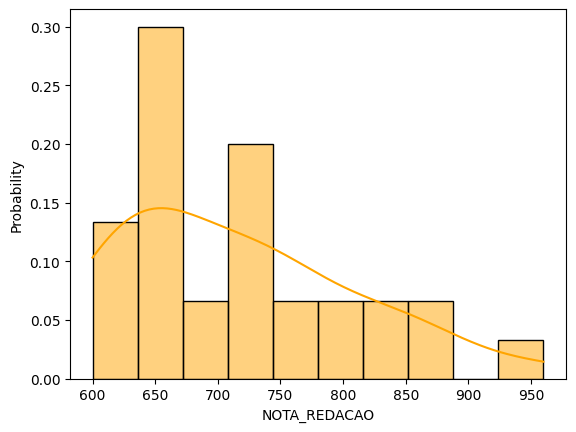

In [24]:
sns.histplot(colegioy, x='NOTA_REDACAO', bins=10, color='orange', kde=True, stat='probability')

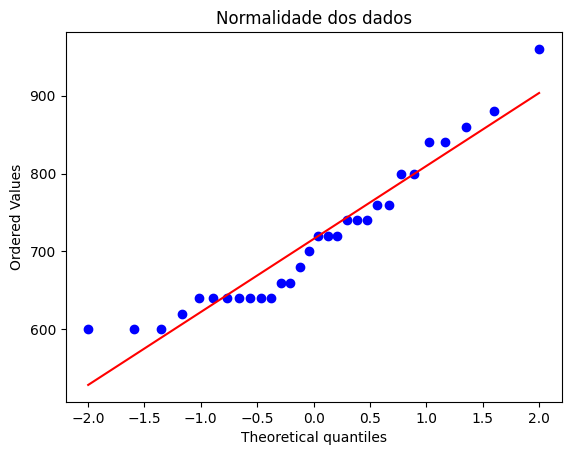

In [27]:
stats.probplot(colegioy['NOTA_REDACAO'], dist='norm', plot=plt)
plt.title('Normalidade dos dados')
plt.show()

Critérios

Nivel de significância de 0,05 ou 5% (mais utilizado)

Quando p>0,05 (distribuição normal).

## **Teste Shapiro-Wilk**

In [28]:
stats.shapiro(colegioy['NOTA_REDACAO'])

ShapiroResult(statistic=0.9185918569564819, pvalue=0.024661008268594742)

## **Teste Lilliefors (Kolmogorov_Sminorv)**

In [30]:
statsmodels.stats.diagnostic.lilliefors(colegioy['NOTA_REDACAO'], dist='norm')

(0.15794211976028916, 0.052842042822119004)

## **Teste Anderson Darling**

In [31]:
stats.anderson(colegioy['NOTA_REDACAO'], 'norm')

AndersonResult(statistic=0.8227980663381267, critical_values=array([0.521, 0.593, 0.712, 0.83 , 0.988]), significance_level=array([15. , 10. ,  5. ,  2.5,  1. ]), fit_result=  params: FitParams(loc=716.0, scale=93.86711076174988)
 success: True
 message: '`anderson` successfully fit the distribution to the data.')

## **Teste T**

Média das Notas do colégio Y, comparada a média do Estado de São Paulo

Ho = média é igual a de Sâo Paulo: p>0.05

Ha= média é diferente da de São Paulo: p <= 0.05

In [32]:
enem_sp.NOTA_REDACAO.describe()

count    499940.000000
mean        593.018322
std         170.536724
min           0.000000
25%         500.000000
50%         600.000000
75%         680.000000
max        1000.000000
Name: NOTA_REDACAO, dtype: float64

In [33]:
stat, p = stats.ttest_1samp(colegioy['NOTA_REDACAO'], popmean=593.018)
print('Estatística de teste: {} '.format(stat.round(2)))
print('p-valor: {}'.format(p.round(10)) )

Estatística de teste: 7.18 
p-valor: 6.72e-08


Teste estatpistico: t = 7,18

p valor = 6.72e-08

Conclusão: Estatisticamente, a média da redação do colégio y é diferente da média do estado de são paulo, com intervalo e confiança de 90%